In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from matplotlib import font_manager

font_path = font_manager.findfont('Microsoft YaHei')
if font_path:
    print(f"Found Microsoft YaHei at: {font_path}")
else:
    print("Microsoft YaHei not found")

Found Microsoft YaHei at: /usr/local/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


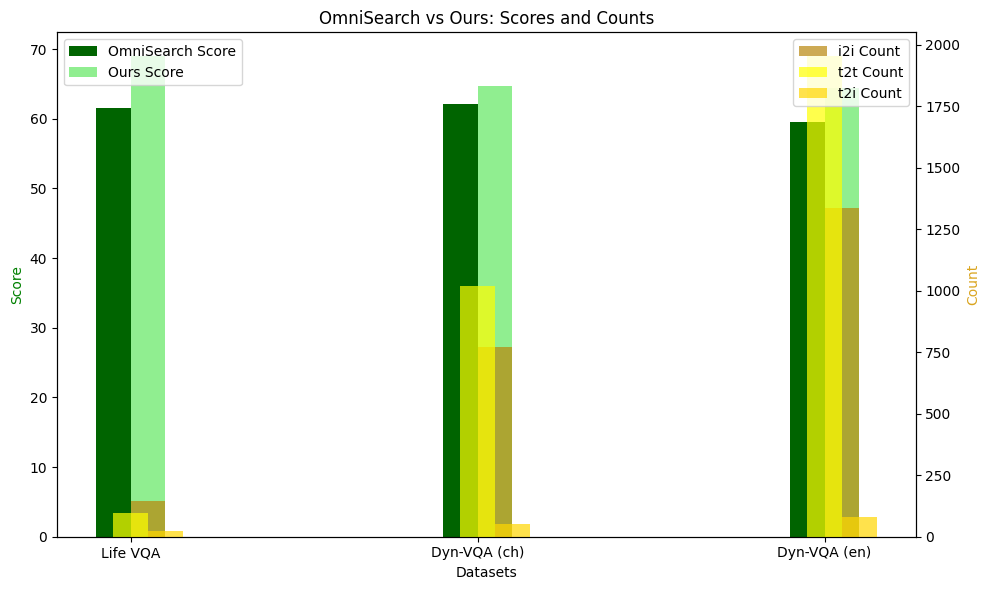

In [27]:
# 数据
labels = ['Life VQA', 'Dyn-VQA (ch)', 'Dyn-VQA (en)']
omni_search_scores = [61.61, 62.06, 59.52]
ours_scores = [68.97, 64.76, 64.44]
i2i_counts = [145, 773, 1338]
t2t_counts = [98, 1018, 1953]
t2i_counts = [24, 53, 80]

x = np.arange(len(labels))  # x轴位置
width = 0.1  # 单柱宽度

# 图表初始化
fig, ax1 = plt.subplots(figsize=(10, 6))

# 双侧纵轴
color_scores = ['darkgreen', 'lightgreen']
color_counts = ['darkgoldenrod', 'yellow']

ax1.bar(x - width / 2, omni_search_scores, width, label='OmniSearch Score', color=color_scores[0])
ax1.bar(x + width / 2, ours_scores, width, label='Ours Score', color=color_scores[1])
ax1.set_xlabel('Datasets')
ax1.set_ylabel('Score', color='green')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend(loc='upper left')

# 次数图表（右侧纵轴）
ax2 = ax1.twinx()
ax2.bar(x + width / 2, i2i_counts, width, label='i2i Count', alpha=0.7, color=color_counts[0])
ax2.bar(x, t2t_counts, width, label='t2t Count', alpha=0.7, color=color_counts[1])
ax2.bar(x + width, t2i_counts, width, label='t2i Count', alpha=0.7, color='gold')
ax2.set_ylabel('Count', color='goldenrod')
ax2.legend(loc='upper right')

# 总体设置
plt.title('OmniSearch vs Ours: Scores and Counts')
plt.tight_layout()
plt.show()

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

font_size_s = 22
font_size_m = 24
font_size_l = 26

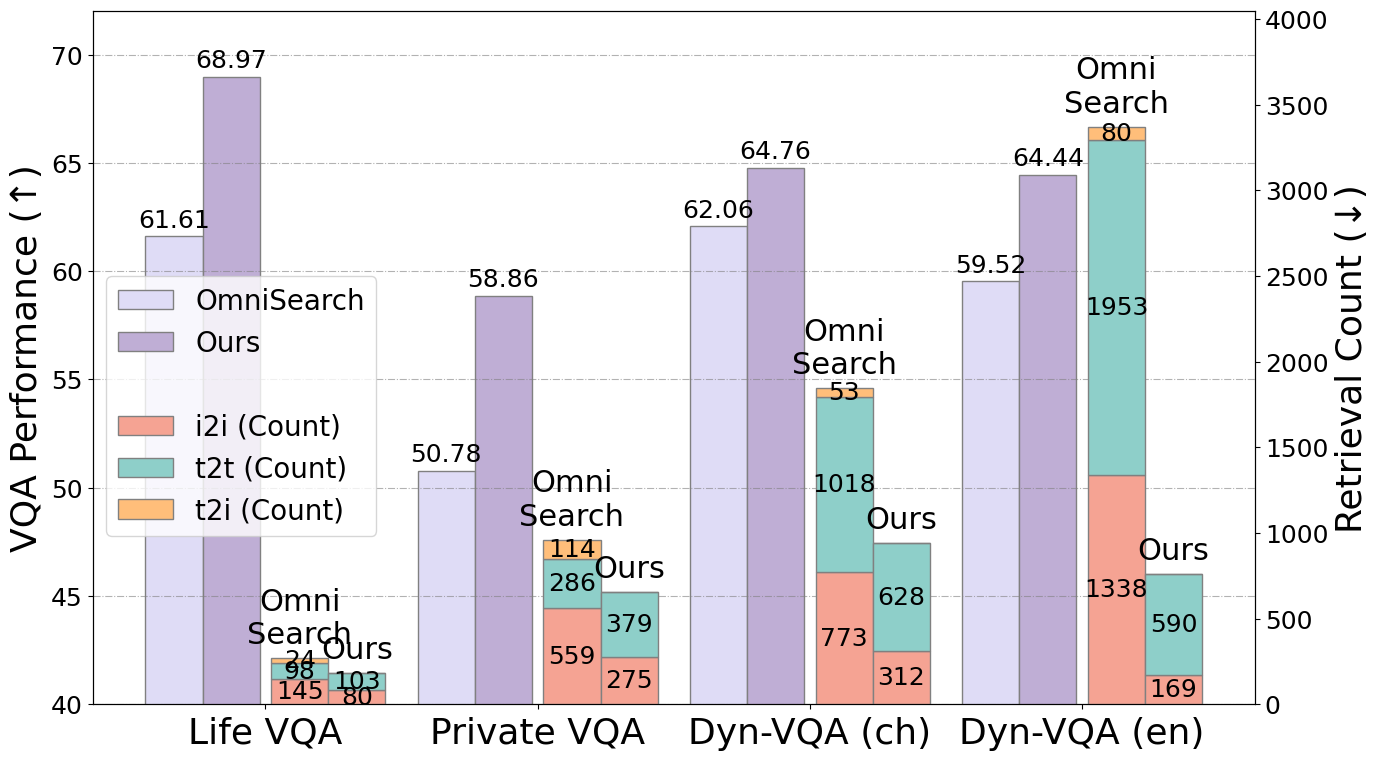

In [38]:
# 1. ==================== 数据参数 ====================
# 您可以在这里修改数据
categories = ['Life VQA', 'Private VQA', 'Dyn-VQA (ch)', 'Dyn-VQA (en)']

# 左侧Y轴数据：分数 (Score)
scores_data = {
    'OmniSearch': [61.61, 50.78, 62.06, 59.52],
    'Ours':       [68.97, 58.86, 64.76, 64.44]
}

# 右侧Y轴数据：次数 (Count)
counts_data = {
    'OmniSearch': {
        'i2i': np.array([145, 559, 773, 1338]),
        't2t': np.array([98, 286, 1018, 1953]),
        't2i': np.array([24, 114, 53, 80])
    },
    'Ours': {
        'i2i': np.array([80, 275, 312, 169]),
        't2t': np.array([103, 379, 628, 590]),
        't2i': np.array([0, 0, 0, 0])
    }
}
# 定义次数的类别顺序
count_keys = ['i2i', 't2t', 't2i']

# 2. ==================== 可视化参数 ====================
# 颜色配置
score_colors = {'OmniSearch': 'palegreen', 'Ours': 'forestgreen'}
count_colors = {'i2i': 'khaki', 't2t': 'gold', 't2i': 'orange'}

score_colors = {'OmniSearch': '#DFDCF6', 'Ours': '#BFAED5'}
count_colors = {'i2i': '#F5A393', 't2t': '#8ECFC9', 't2i': '#FFBE7A'}

# 柱状图位置和宽度参数
x = np.arange(len(categories))  # X轴刻度位置
bar_width = 0.21                 # 单个柱子的宽度
# 为每个类别的四组柱子计算位置
positions = {
    'omni_score': x - 1.6 * bar_width,
    'ours_score': x - 0.6 * bar_width,
    'omni_counts': x + 0.6 * bar_width,
    'ours_counts': x + 1.6 * bar_width
}

# 3. ==================== 开始绘图 ====================
# 创建图表和坐标轴
fig, ax1 = plt.subplots(figsize=(15, 9))
ax2 = ax1.twinx()  # 创建共享X轴的第二个Y轴

# --- 绘制分数柱状图 (左侧Y轴) ---
bar_omni_score = ax1.bar(positions['omni_score'], scores_data['OmniSearch'], bar_width, 
                         label='OmniSearch Score', color=score_colors['OmniSearch'], edgecolor='grey')
bar_ours_score = ax1.bar(positions['ours_score'], scores_data['Ours'], bar_width, 
                         label='Ours Score', color=score_colors['Ours'], edgecolor='grey')

# --- 绘制次数的堆叠柱状图 (右侧Y轴) ---
# 为OmniSearch绘制堆叠柱状图
bottom_omni = np.zeros(len(categories))
omni_bars = {}
for key in count_keys:
    counts = counts_data['OmniSearch'][key]
    
    if key == 'i2i':
        duration = counts*6.4
    elif key == 't2t':
        duration = counts*1.4
    elif key == 't2i':
        duration = counts*1.9
        
    omni_bars[key] = ax2.bar(positions['omni_counts'], counts, bar_width, bottom=bottom_omni, 
                             color=count_colors[key], edgecolor='grey')
    bottom_omni += counts

# 为Ours绘制堆叠柱状图
bottom_ours = np.zeros(len(categories))
ours_bars = {}
for key in count_keys:
    counts = counts_data['Ours'][key]
    if key == 'i2i':
        duration = counts*6.4
    elif key == 't2t':
        duration = counts*1.4
    elif key == 't2i':
        duration = counts*1.9
        
    ours_bars[key] = ax2.bar(positions['ours_counts'], counts, bar_width, bottom=bottom_ours, 
                             color=count_colors[key], edgecolor='grey')
    bottom_ours += counts

# 在堆叠柱状图上方添加文本标签以区分 'OmniSearch' 和 'Ours'
for i, cat in enumerate(categories):
    ax2.text(positions['omni_counts'][i], bottom_omni[i] + 50, 'Omni\nSearch', 
             ha='center', va='bottom', fontsize=font_size_s, fontweight='normal')
    ax2.text(positions['ours_counts'][i], bottom_ours[i] + 50, 'Ours', 
             ha='center', va='bottom', fontsize=font_size_s, fontweight='normal')

# 4. ==================== 添加数据标签 ====================
# 为简单柱状图添加数据标签
def add_bar_labels(bars, ax, fmt='{:.2f}'):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(fmt.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=font_size_s-4)

# 为堆叠柱状图的每个分段添加数据标签
def add_stacked_labels(bars_dict, ax, data_dict, fmt='{:.0f}'):
    bottom = np.zeros(len(categories))
    for key in count_keys:
        heights = data_dict[key]
        for i, bar in enumerate(bars_dict[key]):
            if heights[i] > 0:
                ax.annotate(fmt.format(heights[i]),
                            xy=(bar.get_x() + bar.get_width() / 2, bottom[i] + heights[i] / 2),
                            ha='center', va='center', fontsize=font_size_s-4, color='black')
        bottom += heights

add_bar_labels(bar_omni_score, ax1)
add_bar_labels(bar_ours_score, ax1)
add_stacked_labels(omni_bars, ax2, counts_data['OmniSearch'])
add_stacked_labels(ours_bars, ax2, counts_data['Ours'])

# 5. ==================== 格式化图表 ====================
# 设置坐标轴标签和标题
# ax1.set_xlabel('Dataset', fontsize=font_size_l, fontweight='bold')
# ax1.set_ylabel('VQA Performance (↑)', color=score_colors['Ours'], fontsize=font_size_l, fontweight='bold')
# ax2.set_ylabel('Retrieval Count (↓)', color=count_colors['t2i'], fontsize=font_size_l, fontweight='bold')
ax1.set_ylabel('VQA Performance (↑)', color='black', fontsize=font_size_l, fontweight='normal', labelpad=5)
ax2.set_ylabel('Retrieval Count (↓)', color='black', fontsize=font_size_l, fontweight='normal', labelpad=5)
# ax1.set_title('Comparison of OmniSearch and Ours Agent', fontsize=font_size_l, fontweight='bold')

ax1.tick_params(axis='x', pad=5)

# 设置坐标轴刻度
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=font_size_l)
# ax1.tick_params(axis='y', labelcolor=score_colors['Ours'])
# ax2.tick_params(axis='y', labelcolor=count_colors['t2i'])
ax1.tick_params(axis='y', labelcolor='black', labelsize=font_size_s-4)
ax2.tick_params(axis='y', labelcolor='black', labelsize=font_size_s-4)

# 设置Y轴范围
ax1.set_ylim(40, 72)
ax2.set_ylim(0, max(bottom_omni.max(), bottom_ours.max()) * 1.2) # 留出顶部空间

# 添加网格线
ax1.grid(axis='y', linestyle='dashdot', alpha=0.6, color='gray')

# --- 创建并显示图例 ---
legend_elements = [
    Patch(facecolor=score_colors['OmniSearch'], edgecolor='grey', label='OmniSearch'),
    Patch(facecolor=score_colors['Ours'], edgecolor='grey', label='Ours'),
    Patch(color='white', label='', alpha=0),  # 用作分隔符
    # Patch(color='white', label='Retrieval Types (Count):', alpha=0), # 小标题
    Patch(facecolor=count_colors['i2i'], edgecolor='grey', label='i2i (Count)'),
    Patch(facecolor=count_colors['t2t'], edgecolor='grey', label='t2t (Count)'),
    Patch(facecolor=count_colors['t2i'], edgecolor='grey', label='t2i (Count)'),
]
ax1.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0, 0.43), 
           title=None, fontsize=font_size_s-2, title_fontsize=font_size_s)

# 调整布局以防止图例被裁剪
# fig.tight_layout()
plt.subplots_adjust(right=0.9)

# 显示图表
plt.show()